In [27]:
from  ArtFire.DL.Models.MLP import CustomRegressor
from ArtFire.DL.Optimization.optimizers import build_optimizer, build_parameter_groups
from pytorch_scheduler.scheduler.polynomial import PolynomialScheduler
from pytorch_scheduler.base.warmup import WarmupScheduler
import torch
import matplotlib.pyplot as plt


In [2]:
model=CustomRegressor(input_dim=100, output_dim=10, hidden_layers=[64,32], dropout=0.1, normalization="Batch-Norm", activation="leaky_relu", initialization="default")


In [3]:
model.network

Sequential(
  (0): Linear(in_features=100, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): LeakyReLU(negative_slope=0.01)
  (7): Dropout(p=0.1, inplace=False)
  (8): Linear(in_features=32, out_features=10, bias=True)
)

In [4]:
torch.mean(model.network[0].weight[1])

tensor(0.0027, grad_fn=<MeanBackward0>)

# Split Parameters into regularized ones and non-regularized ones
Do not regularize biases and normalization parameters

In [5]:
parameters_groups=build_parameter_groups(model, 0.0001, 0.00005)
parameters_groups

([['network.0.weight', 'network.4.weight', 'network.8.weight'],
  ['network.0.bias',
   'network.1.weight',
   'network.1.bias',
   'network.4.bias',
   'network.5.weight',
   'network.5.bias',
   'network.8.bias']],
 [{'params': [Parameter containing:
    tensor([[ 0.0554, -0.0103, -0.0876,  ..., -0.0748,  0.0620,  0.0327],
            [ 0.0760,  0.0444, -0.0245,  ...,  0.0129,  0.0476, -0.0356],
            [ 0.0767,  0.0874, -0.0211,  ...,  0.0859, -0.0785, -0.0904],
            ...,
            [ 0.0802,  0.0407,  0.0686,  ..., -0.0968,  0.0748, -0.0315],
            [-0.0184, -0.0967,  0.0771,  ..., -0.0899, -0.0223,  0.0444],
            [ 0.0092,  0.0002,  0.0816,  ..., -0.0060, -0.0120,  0.0883]],
           requires_grad=True),
    Parameter containing:
    tensor([[ 0.0447, -0.0771,  0.0885,  ...,  0.0683,  0.0433, -0.0239],
            [-0.0720,  0.0388, -0.1128,  ...,  0.0141,  0.0239, -0.0432],
            [ 0.0213, -0.0298, -0.0759,  ..., -0.0093, -0.0508,  0.0178],
     

# Set-up an AdamW optimizer with lookahead

In [36]:
optimizer=build_optimizer(params=parameters_groups[1],
   config= {
    "name":"adamw",
    "lr":1e-3,
    "weight_decay":1e-4,
    "use_lookahead": True}
)

In [37]:
optimizer

Lookahead (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 1e-07
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 1e-07
    maximize: False
    weight_decay: 0.0
)

# Set-up a lr scheduler

In [38]:
scheduler= PolynomialScheduler(optimizer=optimizer, total_steps=10000, power=1, min_lr=1e-7)

In [39]:
warmup_scheduler=WarmupScheduler(optimizer, scheduler, warmup_steps=1000, warmup_type="linear")

In [40]:
lrs=[]
for step in range(10000):
    lrs.append(optimizer.param_groups[0]["lr"])
    warmup_scheduler.step()

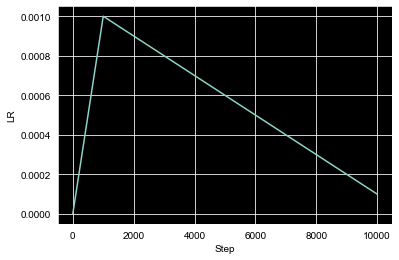

In [41]:
plt.plot(lrs)

plt.xlabel("Step", color="black")
plt.ylabel("LR", color="black")

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.grid(True)

plt.show()